## Análise de Risco de Crédito: Ingestão e Engenharia de Features

**Objetivo:** Consumir os dados originais do *German Credit Dataset* (UCI), realizar a análise exploratória inicial e aplicar o *One-Hot Encoding* nas variáveis categóricas preparando a base para modelagem.

Dados do site: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data 

In [56]:
from ucimlrepo import fetch_ucirepo
  
statlog_german_credit_data = fetch_ucirepo(id=144)
  
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets
  
print(statlog_german_credit_data.metadata)
  
print(statlog_german_credit_data.variables)

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

## Análise de Balanceamento e Outliers

Nesta etapa, entenderemos a distribuição individual dos dados.Primeiro, foi verificada a proporção da variável alvo para identificar se o dataset sofre de desbalanceamento severo (algo comum em cenários de fraude e crédito). Em seguida, utilizamos boxplots nas variáveis numéricas para mapear possíveis outliers que possam distorcer o aprendizado do algoritmo.

> **Nota sobre as variáveis categóricas:** Para as outras 13 variáveis qualitativas (como Histórico de Crédito ou Status da Conta), eventuais desbalanceamentos e "categorias raras" serão avaliados visualmente através da análise de frequência (gráficos de barras) na etapa bivariada.

> **Nota de Negócios:** Os *outliers* detectados nas variáveis contínuas (como altos valores de crédito, prazos longos ou idade avançada) representam perfis financeiros reais e não erros de sistema. Portanto, **eles não serão removidos da base**. Eliminar esses dados deixaria o modelo "cego" justamente para as operações mais sensíveis e de alto risco.

--- BALANCEAMENTO DA VARIÁVEL ALVO ---
             Quantidade  Percentual (%)
class_label                            
Bom (1)             700            70.0
Risco (2)           300            30.0


--- DETECÇÃO DE OUTLIERS (VARIÁVEIS NUMÉRICAS) ---


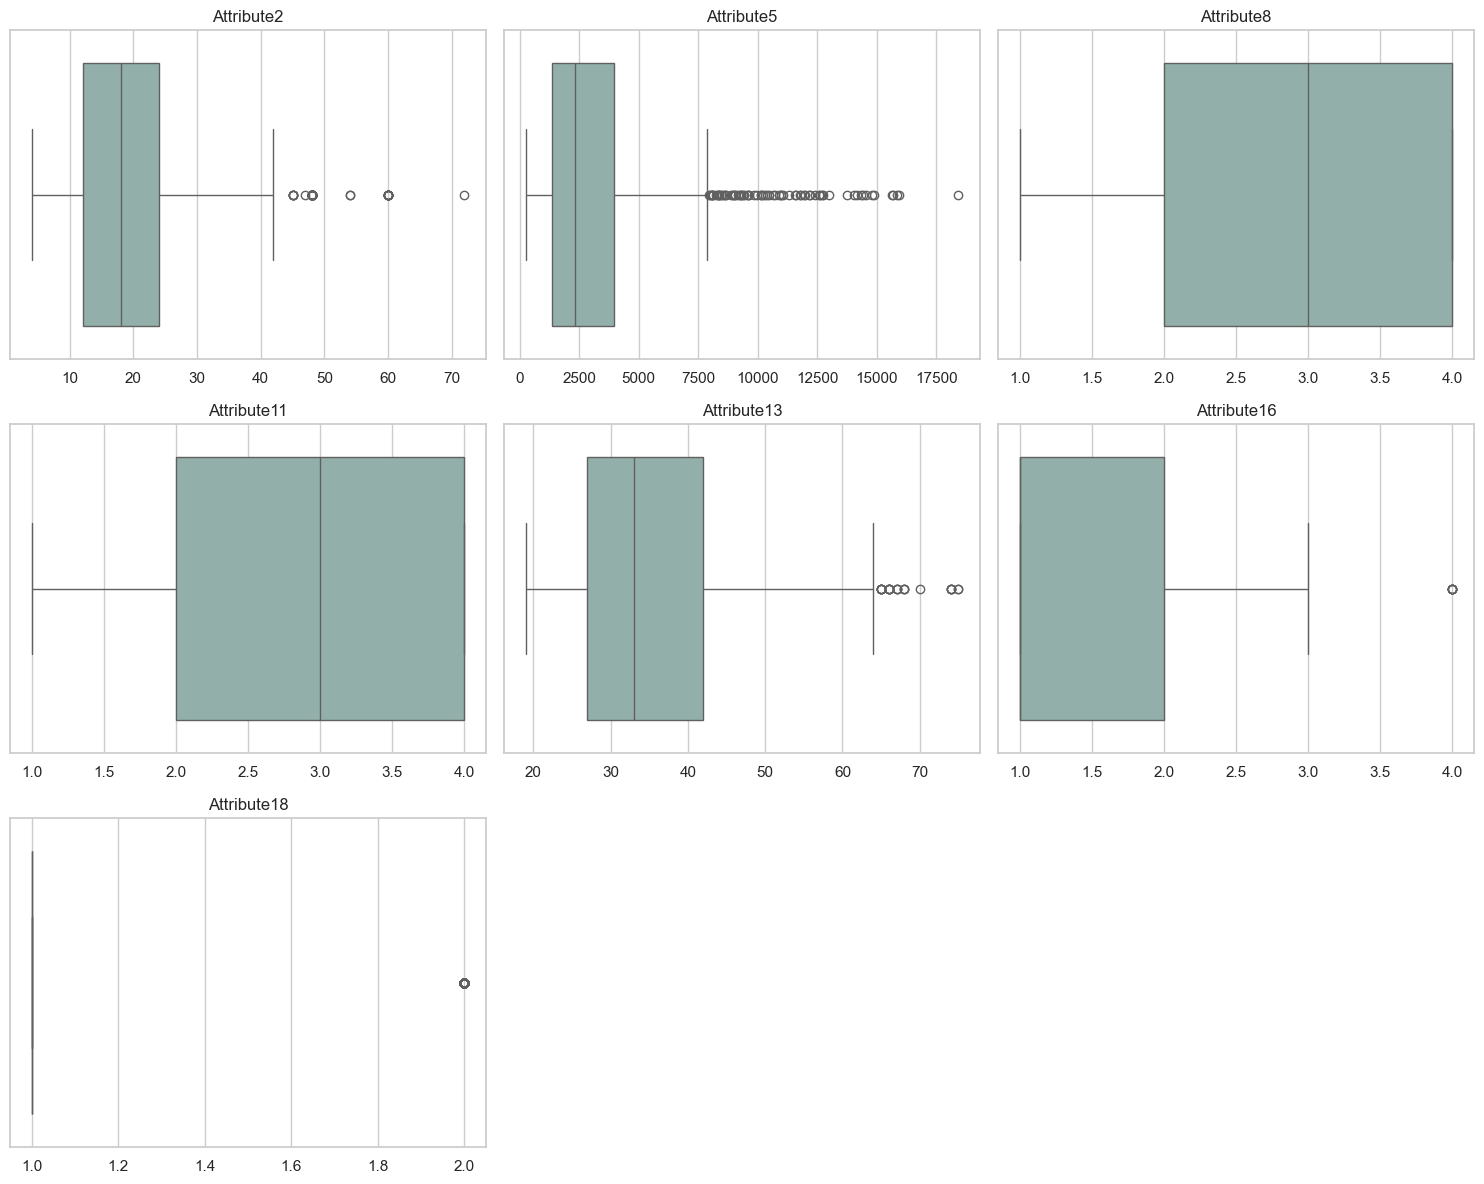

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

#Proporção da variável alvo
print("--- BALANCEAMENTO DA VARIÁVEL ALVO ---")
contagem = df_eda['class_label'].value_counts()
percentual = df_eda['class_label'].value_counts(normalize=True) * 100

resumo_alvo = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': percentual.round(2)
})
print(resumo_alvo)
print("\n")

#Boxplots para detectar Outliers nas variáveis numéricas
print("--- DETECÇÃO DE OUTLIERS (VARIÁVEIS NUMÉRICAS) ---")

linhas_box = math.ceil(len(colunas_numericas) / 3)
plt.figure(figsize=(15, 4 * linhas_box))

for i, coluna in enumerate(colunas_numericas, 1):
    plt.subplot(linhas_box, 3, i)
    sns.boxplot(data=df_eda, x=coluna, color='#8DB4AD')
    plt.title(f'{coluna}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()

## Análise Bivariada: O Perfil do Risco

Com a base validada e o desbalanceamento mapeado, o objetivo agora é cruzar as nossas variáveis com a variável alvo. O intuito é responder à principal pergunta de negócios: **Quais características diferenciam um bom pagador de um cliente de alto risco?**

Os gráficos abaixo exploram essas relações para extrairmos os *insights* que guiarão o algoritmo preditivo.

--- ANÁLISE BIVARIADA: VARIÁVEIS NUMÉRICAS vs ALVO ---


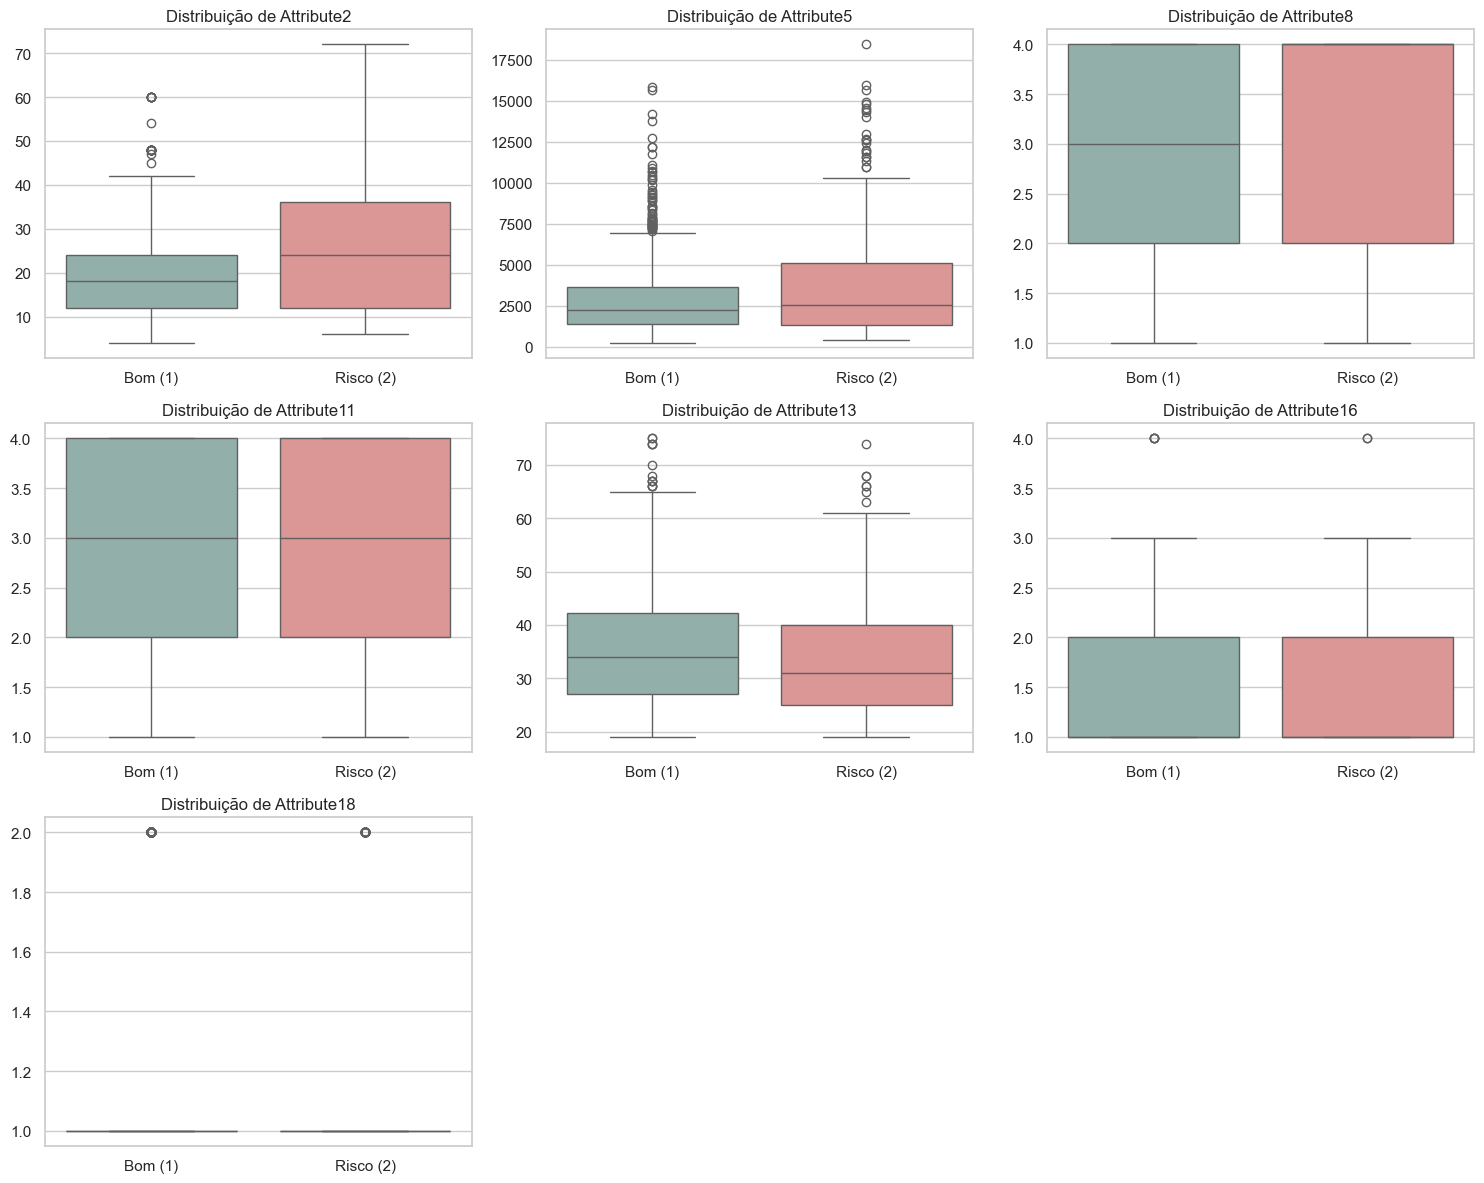


--- ANÁLISE BIVARIADA: VARIÁVEIS CATEGÓRICAS vs ALVO ---


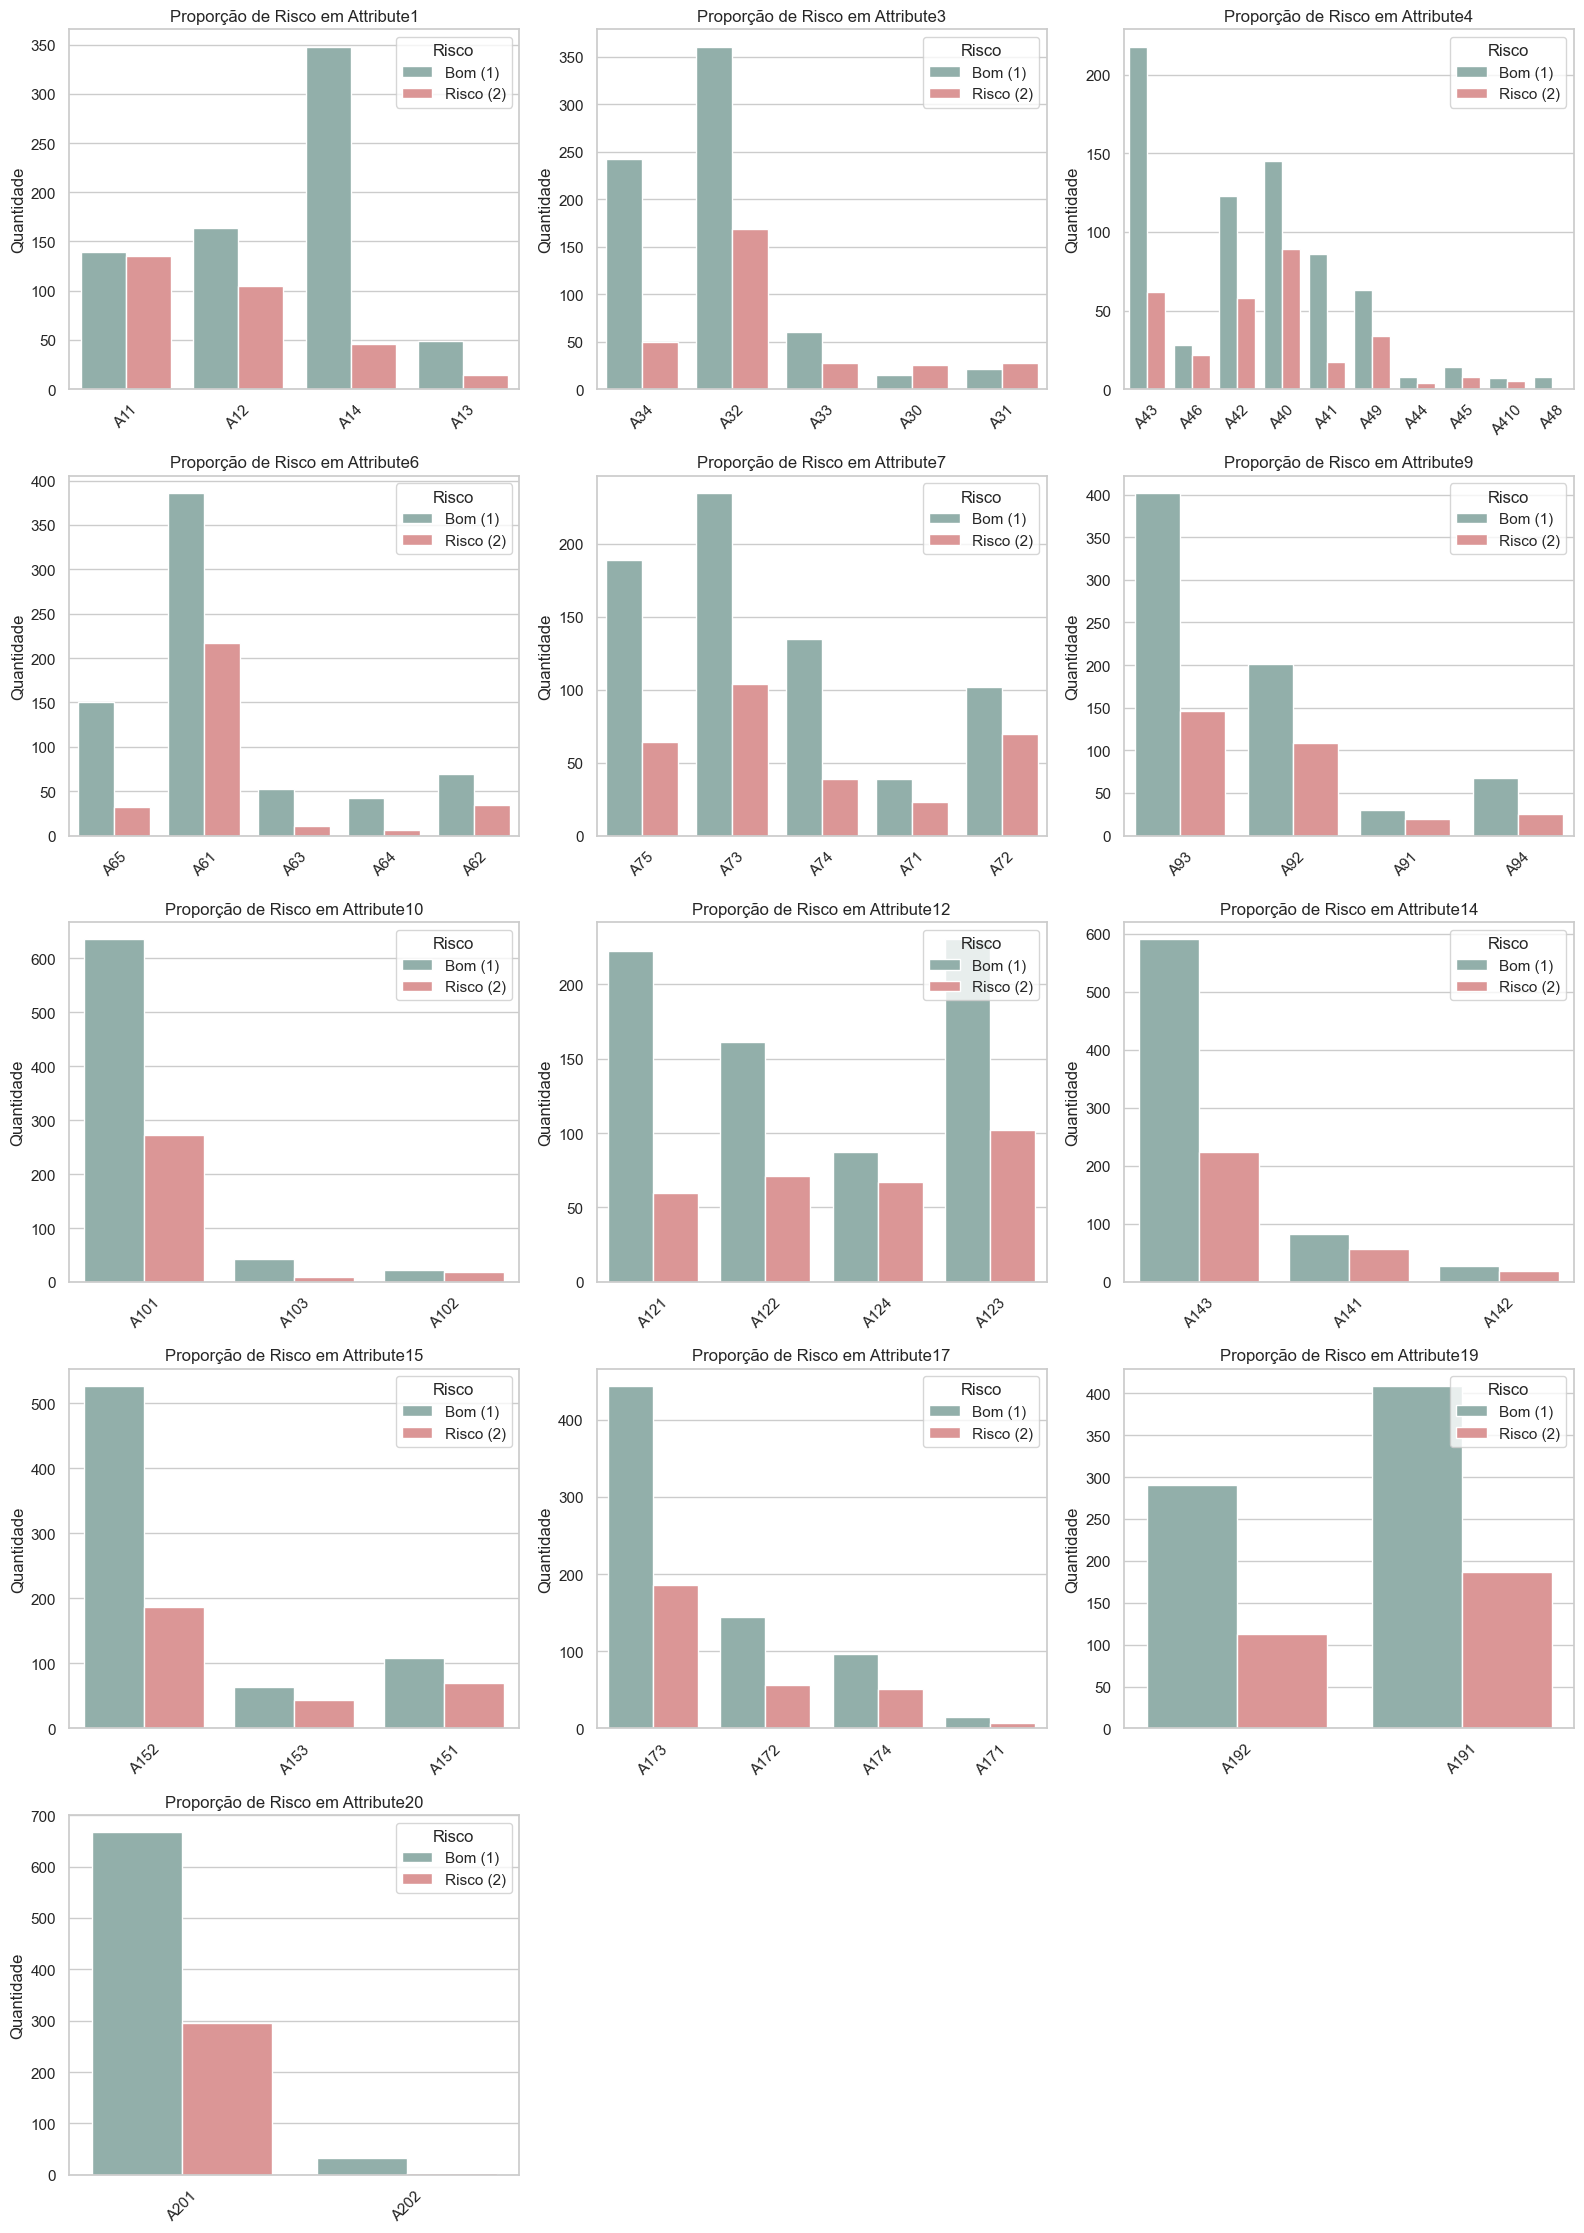

In [58]:
cores_alvo = ['#8DB4AD', '#E68A8A']

print("--- ANÁLISE BIVARIADA: VARIÁVEIS NUMÉRICAS vs ALVO ---")
linhas_num = math.ceil(len(colunas_numericas) / 3)
fig, axes = plt.subplots(linhas_num, 3, figsize=(15, 4 * linhas_num))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x='class_label', y=col, data=df_eda, ax=axes[i], palette=cores_alvo, hue='class_label', legend=False)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

print("\n--- ANÁLISE BIVARIADA: VARIÁVEIS CATEGÓRICAS vs ALVO ---")
colunas_categoricas = [col for col in df_eda.columns if col not in colunas_numericas and col not in ['class', 'class_label']]

linhas_cat = math.ceil(len(colunas_categoricas) / 3)
fig, axes = plt.subplots(linhas_cat, 3, figsize=(16, 4.5 * linhas_cat))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    sns.countplot(x=col, hue='class_label', data=df_eda, ax=axes[i], palette=cores_alvo)
    axes[i].set_title(f'Proporção de Risco em {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Risco', loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


## Pré-processamento de Dados (Pipelines e Transformações)

Com os conjuntos de dados devidamente isolados, blindamos o projeto contra o *Data Leakage* (vazamento de dados). O modelo aprenderá as métricas de padronização exclusivamente no conjunto de **Treino** e apenas aplicará essas regras matemáticas nos conjuntos de **Validação** e **Teste**.

Para orquestrar essa etapa de forma automatizada e escalável, utilizaremos um `ColumnTransformer` do Scikit-Learn com as seguintes etapas:
- **StandardScaler**: Aplicado às variáveis numéricas para nivelar a escala (Média = 0, Desvio Padrão = 1), evitando que variáveis com grandezas maiores (como o valor do crédito) dominem o aprendizado do algoritmo.
- **OneHotEncoder**: Aplicado às variáveis categóricas, convertendo os atributos qualitativos em vetores binários (0 e 1) de forma que o modelo não assuma nenhuma ordem hierárquica inexistente entre as categorias.

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd

print("--- INICIANDO PRÉ-PROCESSAMENTO ---")

colunas_categoricas = [col for col in X_train.columns if col not in colunas_numericas]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

nomes_features = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(X_train_processed, columns=nomes_features)

print(f"Shape original de Treino: {X_train.shape}")
print(f"Shape após o processamento: {X_train_processed_df.shape}")

--- INICIANDO PRÉ-PROCESSAMENTO ---
Shape original de Treino: (650, 20)
Shape após o processamento: (650, 61)


## Modelagem Preditiva e Matriz de Custos de Negócios

Nesta etapa, construiremos os modelos de classificação e aplicaremos a matriz de custos assimétrica definida pelo problema de negócio do *German Credit*. Como aprovar um crédito para um mau pagador é 5x mais custoso do que recusar um bom cliente, o limiar de decisão (*threshold*) padrão de 0.5 será ajustado para minimizar o prejuízo financeiro total.

In [60]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

print("--- TREINAMENTO DO MODELO BASELINE (REGRESSÃO LOGÍSTICA) ---")

# Treinando a Regressão Logística com os dados processados
modelo_baseline = LogisticRegression(random_state=42, max_iter=1000)
modelo_baseline.fit(X_train_processed, y_train)

# Obtendo as probabilidades preditas para o conjunto de validação
# y_val mapeado para binário se necessário (1 = Bom, 2 = Risco)
y_val_bin = y_val.values

# Probabilidade da classe de risco (classe 2)
y_val_prob = modelo_baseline.predict_proba(X_val_processed)[:, 1]

def calcular_custo_total(y_true, y_pred):
    r"""
    Calcula o custo financeiro total baseado na matriz de custos:
    Matriz:
      Real vs Pred | Bom (1) | Risco (2)
      ---------------------------------
      Bom (1)      |    0    |    1
      Risco (2)    |    5    |    0
    """
    # Convertendo y_true e y_pred para formato numérico se necessário
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
    fn_como_bom = cm[1, 0]  # Real = Risco (2), Pred = Bom (1) -> Custo 5
    fp_como_risco = cm[0, 1] # Real = Bom (1), Pred = Risco (2) -> Custo 1
    
    custo_total = (fp_como_risco * 1) + (fn_como_bom * 5)
    return custo_total

# Buscando o melhor threshold
limiares = np.linspace(0.1, 0.9, 81)
melhor_limiar = 0.5
menor_custo = float('inf')

for limiar in limiares:
    y_pred_th = np.where(y_val_prob >= limiar, 2, 1)
    custo = calcular_custo_total(y_val_bin, y_pred_th)
    
    if custo < menor_custo:
        menor_custo = custo
        melhor_limiar = limiar

print(f"Limiar (Threshold) padrão (0.5) - Custo na Validação: {calcular_custo_total(y_val_bin, modelo_baseline.predict(X_val_processed))}")
print(f"Melhor Limiar Otimizado por Custos: {melhor_limiar:.2f} - Menor Custo Total: {menor_custo}")

--- TREINAMENTO DO MODELO BASELINE (REGRESSÃO LOGÍSTICA) ---
Limiar (Threshold) padrão (0.5) - Custo na Validação: 116
Melhor Limiar Otimizado por Custos: 0.15 - Menor Custo Total: 72
